# Random Forest Classification: Fixed Temperature Bins

## Strategy

Instead of creating equal-sized classes by object count, we'll use **fixed temperature ranges** with balanced sampling:

### Temperature Classes (22-25 classes total):
1. **T ≥ 10000K**: 1 class (~5000 hot stars)
2. **7500-10000K**: 500K steps → 5 classes
3. **6000-7500K**: 250K steps → 6 classes
4. **3600-6000K**: 200K steps → 12 classes
5. **T < 3600K**: 1 class (cool stars)

### Sampling Strategy:
- Sample ~5000 objects from each class (matching hot star count)
- Total sample for hyperparameter tuning: ~110,000 objects
- Train final model on full dataset with best parameters

This approach should be much more memory-efficient while maintaining physical interpretability of temperature ranges.


## Import Libraries and Set Parameters

Import required libraries and set global parameters for reproducibility and parallel processing.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import psutil
import os
import sys

sys.path.insert(0, '..')

from src.notebook_utils import load_ml_data, RANDOM_STATE, MISSING_VALUE
from src.config import get_config

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Set random seed for reproducibility
np.random.seed(RANDOM_STATE)

# Parallel processing
N_JOBS = 12  # Use 12 CPU cores

print(f"Random seed: {RANDOM_STATE}")
print(f"CPU cores for training: {N_JOBS}")

## Load Data

Load the ML training dataset with Gaia colors and define color features for temperature prediction.


In [ ]:
# Load data
data = load_ml_data(with_gaia=True, format='pandas')

print(f"Loaded {len(data):,} objects")
print(f"Columns: {list(data.columns)}")

# Define color features
color_features = ['g_r_color', 'r_i_color', 'i_z_color', 'B_V_color', 'bp_rp']

print(f"\nColor features for classification: {color_features}")
print(f"\nData summary:")
print(f"  Temperature range: [{data['teff_gspphot'].min():.0f}, {data['teff_gspphot'].max():.0f}] K")
print(f"  Median temperature: {data['teff_gspphot'].median():.0f} K")

# Check for missing values in features
print(f"\nMissing values:")
for col in color_features + ['teff_gspphot']:
    n_missing = data[col].isna().sum()
    if n_missing > 0:
        print(f"  {col}: {n_missing:,} ({n_missing/len(data)*100:.1f}%)")
    else:
        print(f"No missing values in {col}")


## Create Temperature Classes

Define fixed temperature bins and assign each object to a class based on its temperature.


In [8]:
# Define temperature bin edges
temp_bins = []

# T < 3600K: 1 class (lower bound)
temp_bins.append(0)

# 3600-6000K: 200K steps (12 classes)
temp_bins.extend([3600, 3800, 4000, 4200, 4400, 4600, 4800, 5000, 5200, 5400, 5600, 5800, 6000])

# 6000-7500K: 250K steps (6 classes)
temp_bins.extend([6250, 6500, 6750, 7000, 7250, 7500])

# 7500-10000K: 500K steps (5 classes)
temp_bins.extend([8000, 8500, 9000, 9500, 10000])

# T >= 10000K: 1 class (add upper bound as infinity)
temp_bins.append(np.inf)

print(f"Temperature bin edges: {temp_bins}")
print(f"Number of classes: {len(temp_bins) - 1}")

# Assign temperature classes using pd.cut
data['temp_class'] = pd.cut(data['teff_gspphot'], bins=temp_bins, labels=False, include_lowest=True)

# Count objects per class
class_counts = data['temp_class'].value_counts().sort_index()

print(f"\nObjects per temperature class:")
for cls in range(len(temp_bins) - 1):
    count = class_counts.get(cls, 0)
    temp_min = temp_bins[cls]
    temp_max = temp_bins[cls + 1]
    if temp_max == np.inf:
        print(f"  Class {cls:2d}: [{temp_min:5.0f}K and above) → {count:6,} objects")
    else:
        print(f"  Class {cls:2d}: [{temp_min:5.0f} - {temp_max:5.0f}K) → {count:6,} objects")

print(f"\nTotal classes: {data['temp_class'].nunique()}")
print(f"Objects with assigned class: {data['temp_class'].notna().sum():,}")

# Highlight the hot star class
hot_star_count = class_counts.iloc[-1] if len(class_counts) > 0 else 0
print(f"\n🔥 Hot stars (T ≥ 10000K): {hot_star_count:,} objects")
print(f"   This will be our target sample size per class for hyperparameter tuning.")


Temperature bin edges: [0, 3600, 3800, 4000, 4200, 4400, 4600, 4800, 5000, 5200, 5400, 5600, 5800, 6000, 6250, 6500, 6750, 7000, 7250, 7500, 8000, 8500, 9000, 9500, 10000, inf]
Number of classes: 25

Objects per temperature class:
  Class  0: [    0 -  3600K) → 11,807 objects
  Class  1: [ 3600 -  3800K) → 31,498 objects
  Class  2: [ 3800 -  4000K) → 39,983 objects
  Class  3: [ 4000 -  4200K) → 38,308 objects
  Class  4: [ 4200 -  4400K) → 53,355 objects
  Class  5: [ 4400 -  4600K) → 52,961 objects
  Class  6: [ 4600 -  4800K) → 72,967 objects
  Class  7: [ 4800 -  5000K) → 61,708 objects
  Class  8: [ 5000 -  5200K) → 57,992 objects
  Class  9: [ 5200 -  5400K) → 44,742 objects
  Class 10: [ 5400 -  5600K) → 37,265 objects
  Class 11: [ 5600 -  5800K) → 34,159 objects
  Class 12: [ 5800 -  6000K) → 25,434 objects
  Class 13: [ 6000 -  6250K) → 21,426 objects
  Class 14: [ 6250 -  6500K) → 18,070 objects
  Class 15: [ 6500 -  6750K) → 12,475 objects
  Class 16: [ 6750 -  7000K) →  9

## Visualize Temperature Classes

Plot the temperature distribution with class boundaries to verify the binning strategy.


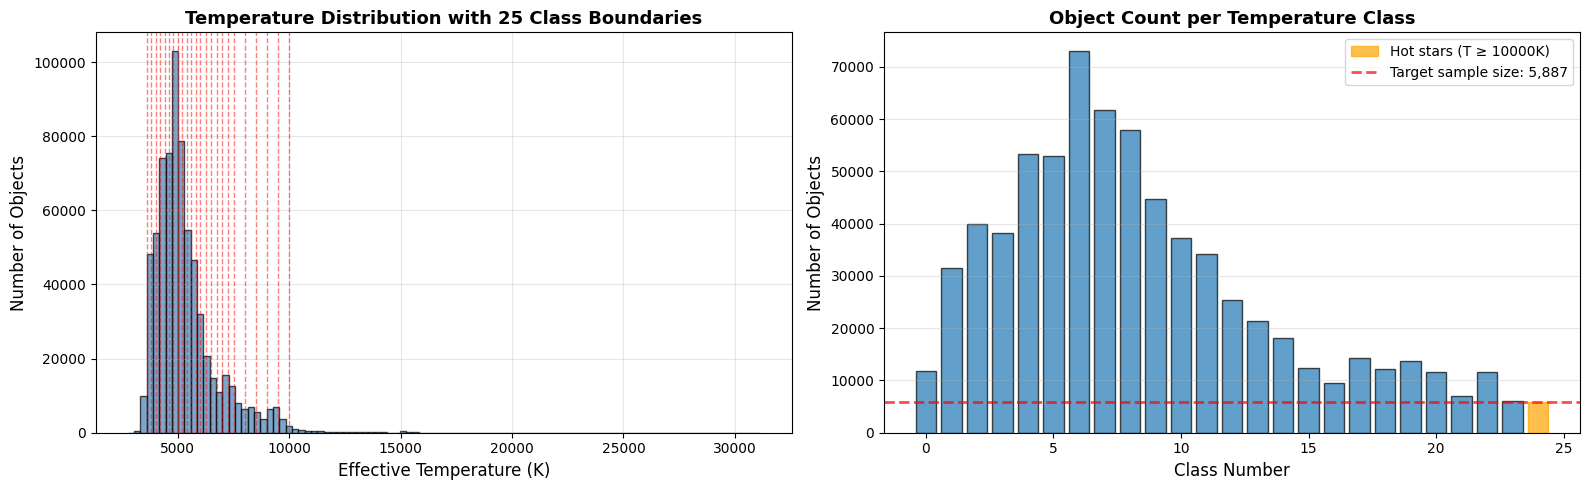

Classes with fewer objects than hot stars: 0 classes


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Temperature histogram with class boundaries
ax = axes[0]
ax.hist(data['teff_gspphot'], bins=100, alpha=0.7, edgecolor='black', color='steelblue')

# Add vertical lines for class boundaries (exclude 0 and inf)
for boundary in temp_bins[1:-1]:
    ax.axvline(boundary, color='red', linestyle='--', alpha=0.5, linewidth=1)

ax.set_xlabel('Effective Temperature (K)', fontsize=12)
ax.set_ylabel('Number of Objects', fontsize=12)
ax.set_title(f'Temperature Distribution with {len(temp_bins)-1} Class Boundaries', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)

# Right: Objects per class (bar plot)
ax = axes[1]
classes = list(range(len(temp_bins) - 1))
counts = [class_counts.get(cls, 0) for cls in classes]

bars = ax.bar(classes, counts, alpha=0.7, edgecolor='black')
# Highlight the hot star class
bars[-1].set_color('orange')
bars[-1].set_label('Hot stars (T ≥ 10000K)')

ax.set_xlabel('Class Number', fontsize=12)
ax.set_ylabel('Number of Objects', fontsize=12)
ax.set_title(f'Object Count per Temperature Class', fontsize=13, fontweight='bold')
ax.axhline(hot_star_count, color='red', linestyle='--', alpha=0.7, linewidth=2, label=f'Target sample size: {hot_star_count:,}')
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"Classes with fewer objects than hot stars: ", end='')
few_objects = [cls for cls in classes if class_counts.get(cls, 0) < hot_star_count]
print(f"{len(few_objects)} classes")


## Create Balanced Sample for Hyperparameter Tuning

Sample ~5000 objects (or the maximum available) from each class to create a balanced training sample for hyperparameter search.


In [ ]:
# Target sample size per class (based on hot star count)
target_sample_size = hot_star_count

print(f"Target sample size per class: {target_sample_size:,}")
print(f"Sampling from {len(temp_bins)-1} classes...\n")

# Sample from each class
sampled_data = []
for cls in range(len(temp_bins) - 1):
    class_data = data[data['temp_class'] == cls]
    n_available = len(class_data)
    n_sample = min(target_sample_size, n_available)
    
    if n_sample > 0:
        class_sample = class_data.sample(n=n_sample, random_state=RANDOM_STATE)
        sampled_data.append(class_sample)
        print(f"  Class {cls:2d}: sampled {n_sample:5,} / {n_available:6,} objects")
    else:
        print(f"  Class {cls:2d}: NO OBJECTS AVAILABLE")

# Combine all samples
balanced_sample = pd.concat(sampled_data, ignore_index=True)

print(f"\n{'='*60}")
print(f"Balanced sample created:")
print(f"  Total objects: {len(balanced_sample):,}")
print(f"  Classes: {balanced_sample['temp_class'].nunique()}")
print(f"  Expected total: ~{target_sample_size * (len(temp_bins)-1):,}")
print(f"{'='*60}")

# Verify balance
sample_class_counts = balanced_sample['temp_class'].value_counts().sort_index()
print(f"\nSample distribution:")
print(f"  Min objects per class: {sample_class_counts.min():,}")
print(f"  Max objects per class: {sample_class_counts.max():,}")
print(f"  Mean objects per class: {sample_class_counts.mean():.0f}")


## Train/Test Split

Split the full dataset into training (80%) and test (20%) sets with stratification to maintain class balance.


In [ ]:
# Prepare features and target from FULL dataset
X = data[color_features].values
y = data['temp_class'].values
temp_actual = data['teff_gspphot'].values  # Keep actual temperatures for evaluation

print(f"Full dataset:")
print(f"  Feature matrix: {X.shape}")
print(f"  Target classes: {y.shape} ({len(np.unique(y))} unique classes)")

# Train/test split (80/20) with stratification
X_train_full, X_test, y_train_full, y_test, temp_train_full, temp_test = train_test_split(
    X, y, temp_actual, 
    test_size=0.2, 
    random_state=RANDOM_STATE,
    stratify=y  # Ensure balanced class distribution in both sets
)

print(f"\nTrain set (full): {len(X_train_full):,} objects ({len(X_train_full)/len(X)*100:.1f}%)")
print(f"Test set:         {len(X_test):,} objects ({len(X_test)/len(X)*100:.1f}%)")
print(f"  Features:       {X_train_full.shape[1]}")

# Verify class distribution
train_class_counts_full = pd.Series(y_train_full).value_counts().sort_index()
test_class_counts = pd.Series(y_test).value_counts().sort_index()

print(f"\nClass distribution in full training set:")
print(f"  Classes: {len(train_class_counts_full)} (min={train_class_counts_full.min():,}, max={train_class_counts_full.max():,})")
print(f"\nClass distribution in test set:")
print(f"  Classes: {len(test_class_counts)} (min={test_class_counts.min():,}, max={test_class_counts.max():,})")

# Prepare balanced sample for hyperparameter tuning
X_tune = balanced_sample[color_features].values
y_tune = balanced_sample['temp_class'].values

print(f"\n{'='*60}")
print(f"Hyperparameter tuning sample:")
print(f"  Objects: {len(X_tune):,}")
print(f"  Features: {X_tune.shape[1]}")
print(f"  Classes: {len(np.unique(y_tune))}")
print(f"{'='*60}")


## Hyperparameter Tuning

Use RandomizedSearchCV on the balanced sample to find optimal hyperparameters. Monitor memory usage and add sound alert when complete.


In [ ]:
# Memory monitoring function
def print_memory_usage():
    process = psutil.Process(os.getpid())
    mem_info = process.memory_info()
    mem_gb = mem_info.rss / 1024**3
    total_mem = psutil.virtual_memory().total / 1024**3
    available_mem = psutil.virtual_memory().available / 1024**3
    print(f"  Memory used by process: {mem_gb:.2f} GB")
    print(f"  Available system memory: {available_mem:.2f} GB / {total_mem:.2f} GB ({available_mem/total_mem*100:.1f}% free)")

print("Initial memory usage:")
print_memory_usage()

# Define hyperparameter grid
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True]
}

print("\nHyperparameter search space:")
for param, values in param_dist.items():
    print(f"  {param:20s}: {values}")

# Create base classifier
N_JOBS_TUNE = 8  # Use 8 cores for tuning
rf_base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=N_JOBS_TUNE)

# Randomized search with cross-validation
print(f"\nStarting RandomizedSearchCV on balanced sample...")
print(f"  Sample size: {len(X_tune):,} objects")
print(f"  Iterations: 30")
print(f"  Cross-validation folds: 3")
print(f"  Parallel jobs: {N_JOBS_TUNE}")

random_search = RandomizedSearchCV(
    rf_base,
    param_distributions=param_dist,
    n_iter=30,
    cv=3,
    scoring='accuracy',
    n_jobs=N_JOBS_TUNE,
    random_state=RANDOM_STATE,
    verbose=2
)

# Fit the model on balanced sample
random_search.fit(X_tune, y_tune)

print(f"\n✓ Best parameters found:")
for param, value in random_search.best_params_.items():
    print(f"  {param:20s}: {value}")
print(f"\nBest cross-validation accuracy: {random_search.best_score_:.4f}")

print("\nMemory usage after hyperparameter tuning:")
print_memory_usage()

# Train final model on FULL training set with best parameters
print("\n" + "="*70)
print("Training final model on full training set...")
print("="*70)

best_rf = RandomForestClassifier(
    **random_search.best_params_,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    verbose=1
)

best_rf.fit(X_train_full, y_train_full)

print("\n✓ Final model trained on full training set")
print(f"  Training samples: {len(X_train_full):,}")
print(f"  Features: {X_train_full.shape[1]}")
print(f"  Classes: {len(np.unique(y_train_full))}")

print("\nFinal memory usage:")
print_memory_usage()

# Play sound to signal completion
print('\a')  # Terminal bell
print("🔔 Training complete!")


## Model Evaluation

Evaluate the trained Random Forest classifier on the test set and analyze performance metrics.


In [15]:
# Make predictions on test set
y_pred = best_rf.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Calculate class prediction errors (how far off the predicted class is)
class_errors = np.abs(y_test - y_pred)
print(f"\nClass Prediction Analysis:")
print(f"  Perfect predictions (error = 0): {np.sum(class_errors == 0):,} ({np.sum(class_errors == 0)/len(y_test)*100:.1f}%)")
print(f"  Close predictions (error ≤ 1): {np.sum(class_errors <= 1):,} ({np.sum(class_errors <= 1)/len(y_test)*100:.1f}%)")
print(f"  Close predictions (error ≤ 2): {np.sum(class_errors <= 2):,} ({np.sum(class_errors <= 2)/len(y_test)*100:.1f}%)")
print(f"  Mean class error: {np.mean(class_errors):.2f} classes")
print(f"  Median class error: {np.median(class_errors):.1f} classes")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion matrix shape: {cm.shape}")

# Show classification report
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.6s


Test Set Accuracy: 0.2908 (29.08%)

Class Prediction Analysis:
  Perfect predictions (error = 0): 41,065 (29.1%)
  Close predictions (error ≤ 1): 71,873 (50.9%)
  Close predictions (error ≤ 2): 85,686 (60.7%)
  Mean class error: 3.23 classes
  Median class error: 1.0 classes

Confusion matrix shape: (25, 25)

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.25      0.37      2361
           1       0.22      0.85      0.35      6300
           2       0.25      0.41      0.31      7997
           3       0.26      0.43      0.33      7662
           4       0.30      0.49      0.37     10671
           5       0.31      0.36      0.33     10592
           6       0.35      0.36      0.35     14594
           7       0.32      0.27      0.29     12342
           8       0.35      0.28      0.31     11599
           9       0.33      0.26      0.29      8948
          10       0.33      0.21      0.25      7453
          11     

[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    2.0s finished


## Confusion Matrix Visualization

Plot the confusion matrix to analyze classification patterns and see if misclassifications are to nearby temperature classes.


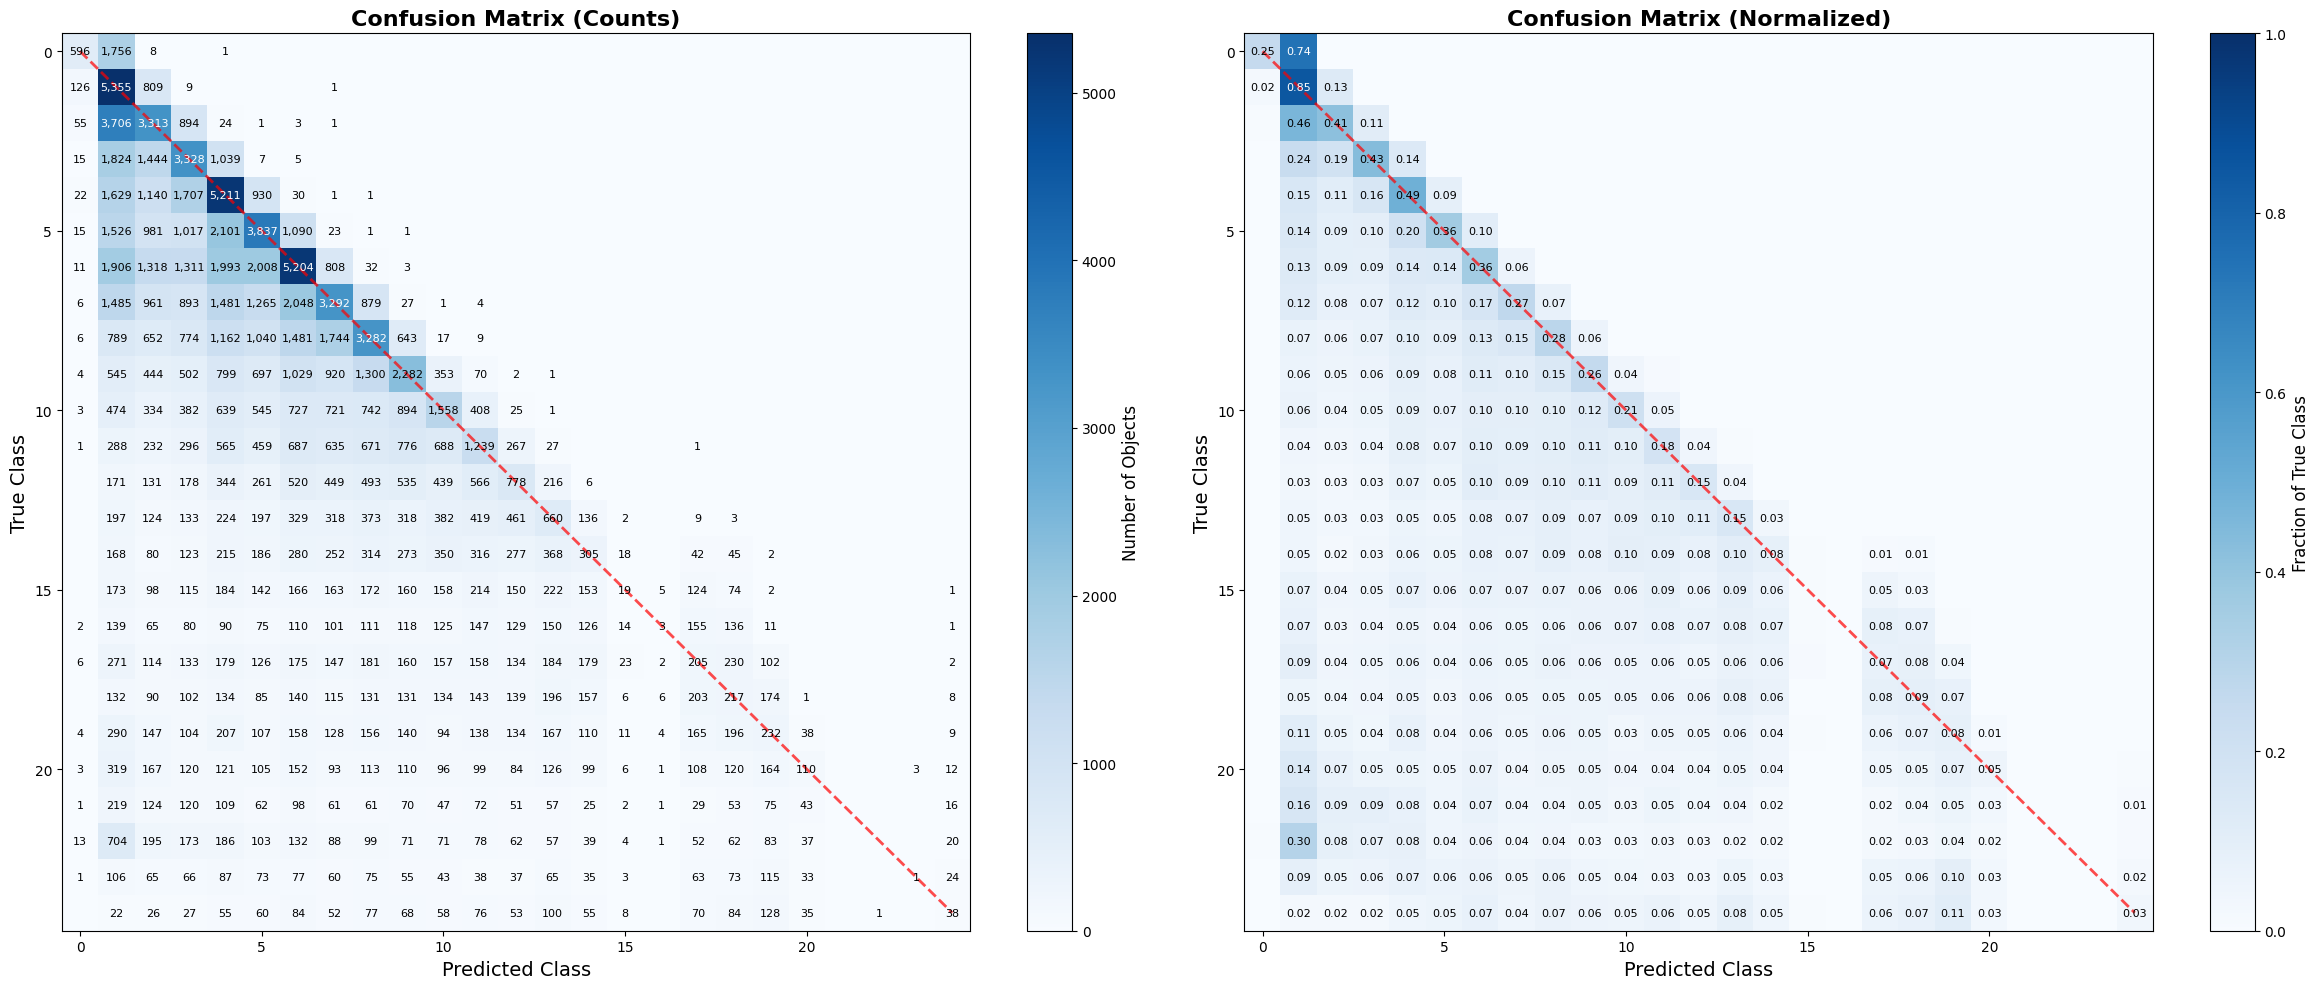

Confusion Matrix Analysis:
  Diagonal elements (correct): 41,065
  Off-diagonal elements (incorrect): 100,135
  Diagonal fraction: 0.291

Nearby class error analysis:
  Errors to adjacent class (±1): 30,808
  Errors to nearby class (±2): 13,813
  Errors to distant class (>2): 55,514

Temperature ranges for selected classes:
  Class  0:     0 - 3600K
  Class  5:  4400 - 4600K
  Class 10:  5400 - 5600K
  Class 15:  6500 - 6750K
  Class 20:  8000 - 8500K
  Class 24: 10000 - infK


In [17]:
# Create confusion matrix visualization with numbers
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# Left: Full confusion matrix with numbers
ax = axes[0]
im = ax.imshow(cm, cmap='Blues', aspect='auto')
ax.set_xlabel('Predicted Class', fontsize=14)
ax.set_ylabel('True Class', fontsize=14)
ax.set_title('Confusion Matrix (Counts)', fontsize=16, fontweight='bold')

# Add numbers to each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if cm[i, j] > 0:  # Only show non-zero values
            ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center', 
                   fontsize=8, color='white' if cm[i, j] > cm.max()/2 else 'black')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Number of Objects', fontsize=12)

# Right: Normalized confusion matrix with percentages
ax = axes[1]
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
im = ax.imshow(cm_norm, cmap='Blues', aspect='auto', vmin=0, vmax=1)
ax.set_xlabel('Predicted Class', fontsize=14)
ax.set_ylabel('True Class', fontsize=14)
ax.set_title('Confusion Matrix (Normalized)', fontsize=16, fontweight='bold')

# Add percentages to each cell
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        if cm_norm[i, j] > 0.01:  # Only show values > 1%
            ax.text(j, i, f'{cm_norm[i, j]:.2f}', ha='center', va='center', 
                   fontsize=8, color='white' if cm_norm[i, j] > 0.5 else 'black')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Fraction of True Class', fontsize=12)

# Add diagonal line for perfect predictions
for ax in axes:
    ax.plot([0, cm.shape[0]-1], [0, cm.shape[1]-1], 'r--', alpha=0.7, linewidth=2)

plt.tight_layout()
plt.show()

# Analyze confusion patterns
print("Confusion Matrix Analysis:")
print(f"  Diagonal elements (correct): {np.trace(cm):,}")
print(f"  Off-diagonal elements (incorrect): {np.sum(cm) - np.trace(cm):,}")
print(f"  Diagonal fraction: {np.trace(cm) / np.sum(cm):.3f}")

# Check if errors are to nearby classes
print(f"\nNearby class error analysis:")
print(f"  Errors to adjacent class (±1): {np.sum((class_errors == 1)):,}")
print(f"  Errors to nearby class (±2): {np.sum((class_errors == 2)):,}")
print(f"  Errors to distant class (>2): {np.sum((class_errors > 2)):,}")

# Show temperature ranges for some classes
print(f"\nTemperature ranges for selected classes:")
for cls in [0, 5, 10, 15, 20, 24]:  # Show a few classes
    if cls < len(temp_bins) - 1:
        temp_min = temp_bins[cls]
        temp_max = temp_bins[cls + 1] if cls + 1 < len(temp_bins) else "∞"
        print(f"  Class {cls:2d}: {temp_min:5.0f} - {temp_max}K")
